#

In [1]:
import pulp
import networkx as nx
import matplotlib.pyplot as plt

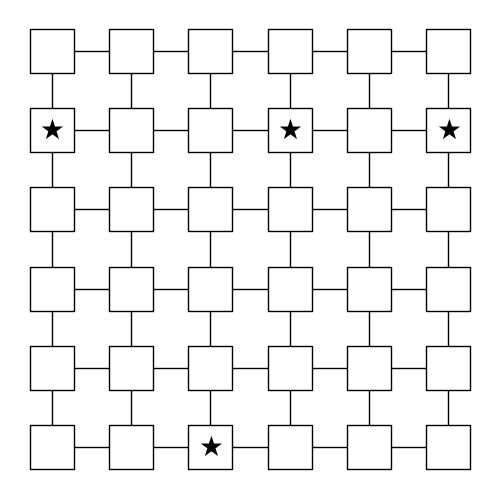

In [2]:
rows = 6
cols = 6
G = nx.grid_2d_graph(rows, cols)
pos = {(x, y): (y, -x) for x, y in G.nodes()}
nx.draw(G,
        pos,
        node_color="white",
        edgecolors="black",
        node_size=1000,
        node_shape='s'
       )
starred_nodes = {(1,0),(1,3),(1,5),(5,2)}
star_labels = {n: "★" for n in starred_nodes} 
nx.draw_networkx_labels(G, pos, labels=star_labels, font_size=20, font_color='black')
plt.gca().set_aspect("equal")
plt.show()

In [3]:
OFFSETS = [
([(0,0),(0,1)],1), # vertical domino
([(0,0),(1,0)],2), # horizontal domino
]
COLORS = dict(zip([1,2],[
    "#1f77b4",  # blue
    "#d62728",  # red
]))

dominoes = []
starred = []
non_starred = []
for node in G.nodes():
    x0, y0 = node
    for offset,id in OFFSETS:
        T = [(x0 + dx, y0 + dy) for (dx, dy) in offset]
        if all(G.has_node(v) for v in T): 
            P=G.subgraph(T).copy()
            P.graph["color"] = COLORS[id]
            dominoes.append(P)
            if not starred_nodes.isdisjoint(P.nodes()):
                starred.append(P)
            else:
                non_starred.append(P)
dominoes_dict = dict(zip([i for i in range(len(dominoes))],dominoes))

starred_neighbors = {}
for p in non_starred:
    starred_neighbors[p] = []
    for q in starred:
        boundary_p = nx.node_boundary(G, p)
        if not boundary_p.isdisjoint(q):
            starred_neighbors[p].append(q)

In [4]:
# create problem
prob = pulp.LpProblem("starred_dominoes", pulp.LpMinimize)

# x[p] = 1 dominoe p is used
x = pulp.LpVariable.dicts("x",dominoes_dict,cat=pulp.LpBinary)

# dummy objective
prob+= 0 

# no overlap
for (r,c) in G.nodes():
    prob+= pulp.lpSum(x[p] for p in dominoes_dict if (r,c) in dominoes_dict[p].nodes()) == 1

# selection of non starred domino => selection of one of its adjacent starred dominoes
for p in dominoes_dict:
    P = dominoes_dict[p]
    if P in non_starred:
        prob+= x[p] <= pulp.lpSum(x[q] for q in dominoes_dict if dominoes_dict[q] in starred_neighbors[P])

In [5]:
prob.solve()

1

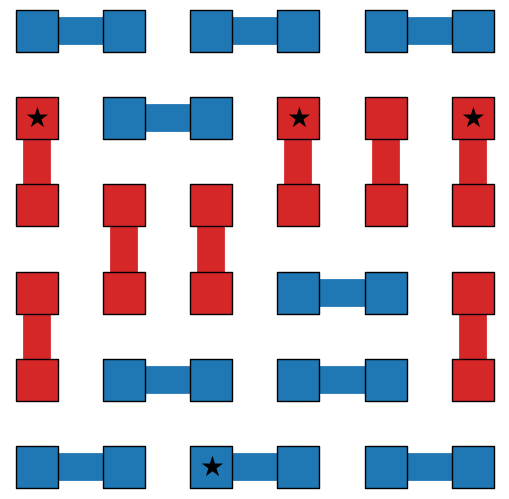

In [7]:
for p in x:
    if pulp.value(x[p])>0.9:
        P = dominoes_dict[p]
        nx.draw(P, 
                pos, 
                node_color=P.graph["color"],
                edgecolors="black",
                edge_color=P.graph["color"],
                node_size=900,
                node_shape='s',
                width=20)
nx.draw_networkx_labels(G, pos, labels=star_labels, font_size=20, font_color='black')
plt.gca().set_aspect("equal")
plt.show()